# 🏆 FIFA Player Position Classification using KNN
### AI Committee — KNN Revision Task
**Name:** Ahmed El Attar | **Date:** Mon, 2 Mar 2026

## Objective
Classify FIFA players into 4 positions (GK, DEF, MID, FWD) 
using K-Nearest Neighbors algorithm on FIFA 15/16 dataset.

In [1]:
# ── Core Libraries ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# ── ML Libraries ──
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# ── Settings ──
pd.set_option('display.max_columns', 50)
import warnings; warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Section 2: Data Loading & Initial Exploration
Let's load the dataset and understand its structure before any cleaning.

In [2]:
df = pd.read_csv('/Users/ahmedelattar/Documents/Artificial Intelligence/MR_AI_Committee/My_Season/FIFA_KNN_Revision_Task/players_16.csv', low_memory=False)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head(3)

Rows: 14,881 | Columns: 104


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,...,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,28,1987-06-24,170,72,Argentina,FC Barcelona,94,95,111000000,550000,"RW, CF",Left,5,4,4,Medium/Low,Messi,Yes,NaN,"#Speedster, #Dribbler, #FK Specialist, #Acroba...",RW,...,87+3,87+3,91+3,91+3,91+3,91+3,91+3,91+3,91+3,91+3,90+3,82+3,82+3,82+3,90+3,62+3,57+3,57+3,57+3,62+3,57+3,44+3,44+3,44+3,57+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,30,1985-02-05,185,80,Portugal,Real Madrid,93,93,85500000,475000,"LW, LM",Right,5,4,5,High/Low,C. Ronaldo,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LM,...,91+3,91+3,90+3,91+3,91+3,91+3,90+3,88+3,88+3,88+3,88+3,80+3,80+3,80+3,88+3,64+3,60+3,60+3,60+3,64+3,60+3,52+3,52+3,52+3,60+3
2,9014,https://sofifa.com/player/9014/arjen-robben/16...,A. Robben,Arjen Robben,31,1984-01-23,180,80,Netherlands,FC Bayern München,90,90,56000000,250000,"RM, LM, RW",Left,5,2,4,High/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",SUB,...,84+3,84+3,89+3,88+3,88+3,88+3,89+3,88+3,88+3,88+3,87+3,80+3,80+3,80+3,87+3,65+3,60+3,60+3,60+3,65+3,59+3,47+3,47+3,47+3,59+3


In [3]:
# Quick overview
print("=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== Missing Values (Top 20) ===")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(20))

=== Data Types ===
object     76
float64    17
int64      11
Name: count, dtype: int64

=== Missing Values (Top 20) ===
release_clause_eur      14881
mentality_composure     14881
nation_position         13871
nation_jersey_number    13871
loaned_from             13827
player_tags             13625
gk_handling             13263
gk_positioning          13263
gk_speed                13263
gk_reflexes             13263
gk_kicking              13263
gk_diving               13263
player_traits            8119
lwb                      1618
ram                      1618
lm                       1618
lcm                      1618
cm                       1618
rcb                      1618
rcm                      1618
dtype: int64


## 🧹 Section 3: Data Cleaning

### Why is cleaning crucial here?
FIFA raw data contains:
- Money values stored as strings (€100M, €50K)
- Height/Weight in mixed formats ("5'11\", 170lbs")
- Many irrelevant columns (photo URLs, club logos, etc.)
- Missing values in key stats

In [4]:
# Make A Copy From Our DataSet
df_cleaned = df.copy()

# These columns add no predictive value for position classification
cols_to_drop = ['sofifa_id', 'player_url', 'short_name',
                'long_name', 'nationality', 'body_type',
                'club', 'real_face', 'release_clause_eur', 'mentality_composure', 'nation_position', 'nation_jersey_number',
                'loaned_from', 'player_tags']

df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns], inplace=True)

print(f"✅ Dropped irrelevant columns | Remaining: {df_cleaned.shape[1]} columns")

# Convert Categorical Columns To Category DataType
cat_cols = cat_cols = df_cleaned.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].astype('category')

# Convert Numeric Columns To Numeric DataType
num_cols = df_cleaned.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors = 'coerce')

for col in df_cleaned.select_dtypes(include=['int64', 'float64']).columns:
    original_dtype = df_cleaned[col].dtype
    
    # For integer columns
    if original_dtype == 'int64':
        if df_cleaned[col].min() >= 0 and df_cleaned[col].max() <= 255:
            df_cleaned[col] = df_cleaned[col].astype('uint8')
        elif df_cleaned[col].min() >= 0 and df_cleaned[col].max() <= 65535:
            df_cleaned[col] = df_cleaned[col].astype('uint16')
        elif df_cleaned[col].min() >= -32768 and df_cleaned[col].max() <= 32767:
            df_cleaned[col] = df_cleaned[col].astype('int16')
        elif df_cleaned[col].min() >= -2147483648 and df_cleaned[col].max() <= 2147483647:
            df_cleaned[col] = df_cleaned[col].astype('int32')
    
    # For float columns
    elif original_dtype == 'float64':
        if df_cleaned[col].min() >= -3.4e38 and df_cleaned[col].max() <= 3.4e38:
            df_cleaned[col] = df_cleaned[col].astype('float32')
    
    if df_cleaned[col].dtype != original_dtype:
        print(f'Optimized {col}: {original_dtype} -> {df_cleaned[col].dtype}')

# Memory usage comparison
original_memory = df.memory_usage(deep=True).sum() / 1024**2
optimized_memory = df_cleaned.memory_usage(deep=True).sum() / 1024**2
print(f'\nMemory usage - Original: {original_memory:.2f} MB')
print(f'Memory usage - Optimized: {optimized_memory:.2f} MB')
print(f'Memory reduction: {(original_memory - optimized_memory):.2f} MB ({((original_memory - optimized_memory)/original_memory*100):.1f}%)')

✅ Dropped irrelevant columns | Remaining: 90 columns
Optimized age: int64 -> uint8
Optimized height_cm: int64 -> uint8
Optimized weight_kg: int64 -> uint8
Optimized overall: int64 -> uint8
Optimized potential: int64 -> uint8
Optimized value_eur: int64 -> int32
Optimized wage_eur: int64 -> int32
Optimized international_reputation: int64 -> uint8
Optimized weak_foot: int64 -> uint8
Optimized skill_moves: int64 -> uint8
Optimized team_jersey_number: float64 -> float32
Optimized contract_valid_until: float64 -> float32
Optimized pace: float64 -> float32
Optimized shooting: float64 -> float32
Optimized passing: float64 -> float32
Optimized dribbling: float64 -> float32
Optimized defending: float64 -> float32
Optimized physic: float64 -> float32
Optimized gk_diving: float64 -> float32
Optimized gk_handling: float64 -> float32
Optimized gk_kicking: float64 -> float32
Optimized gk_reflexes: float64 -> float32
Optimized gk_speed: float64 -> float32
Optimized gk_positioning: float64 -> float32



In [5]:
df_cleaned.columns.to_list()

['age',
 'dob',
 'height_cm',
 'weight_kg',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'player_positions',
 'preferred_foot',
 'international_reputation',
 'weak_foot',
 'skill_moves',
 'work_rate',
 'team_position',
 'team_jersey_number',
 'joined',
 'contract_valid_until',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'gk_diving',
 'gk_handling',
 'gk_kicking',
 'gk_reflexes',
 'gk_speed',
 'gk_positioning',
 'player_traits',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'me

In [6]:
def convert_money(val):
    """Convert €100M → 100000000, €50K → 50000"""
    if pd.isnull(val):
        return np.nan
    val = str(val).replace('€', '').replace(',', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        try: return float(val)
        except: return np.nan

for col in ['value_eur', 'wage_eur']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].apply(convert_money)

print("✅ Money columns converted to numeric")
df_cleaned[['value_eur', 'wage_eur']].describe()

✅ Money columns converted to numeric


,value_eur,wage_eur
count,1.488100e+04,14881.000000
mean,1.766313e+06,14734.359250
std,4.172073e+06,25239.472577
min,0.000000e+00,0.000000
25%,2.500000e+05,1000.000000
50%,5.750000e+05,4000.000000
75%,1.400000e+06,20000.000000
max,1.110000e+08,550000.000000


In [7]:
unique_positions = df_cleaned['player_positions'].unique().tolist()
print(f"Unique positions: {unique_positions}")

Unique positions: ['RW, CF', 'LW, LM', 'RM, LM, RW', 'GK', 'ST', 'LM', 'LW', 'CB', 'CAM, LM', 'CAM, CM, RM', 'RM, RW', 'CM, CDM', 'CAM, LW', 'CDM, RB, CM', 'CM, CAM', 'CM', 'CAM, LM, RM', 'LW, RW', 'LM, CAM', 'CDM', 'CF, RM, CAM, ST', 'ST, CM, CAM', 'ST, CF', 'CM, CAM, CDM', 'LB, CM, CB, CDM', 'CAM, CM, LM', 'ST, LW, RW', 'CAM, RM', 'CAM, LW, CM', 'LB', 'CAM, LM, CF, CM', 'ST, RW', 'CM, LW, RW', 'CDM, CM', 'CB, CDM, CM', 'CM, CDM, CAM', 'CAM', 'RB', 'RM, CAM', 'RW, ST, RM', 'ST, CAM, LM', 'CAM, LM, RM, CM', 'RM, RW, CF', 'RM, LM', 'CB, RB, LB', 'CB, LB', 'CB, CDM', 'CAM, CDM', 'LM, RM', 'RW', 'LM, ST, RM', 'CM, RW, CDM', 'CAM, CF', 'RW, CAM, ST', 'CAM, CDM, CM, CF', 'CDM, CB', 'RW, RM', 'ST, RM, RW', 'CAM, LM, CDM, CM', 'CAM, LM, CF', 'RB, RM', 'RM, ST, LM', 'LW, CAM', 'CB, RB', 'CAM, CM', 'RB, RWB, LWB', 'RM, LM, CAM', 'CAM, ST, RW', 'CB, CDM, RB', 'RM, ST', 'ST, CAM', 'CF, ST, CAM', 'CF', 'LB, LM', 'CF, LW', 'CM, CDM, RM, RB', 'CAM, RW', 'CF, ST', 'RW, RM, LW', 'RB, CB', 'RM, ST, CF'

In [8]:
# Map detailed positions → 4 main categories
pos_map = {
    'GK': 'GK',
    'CB':'DEF','LB':'DEF','RB':'DEF','LWB':'DEF','RWB':'DEF','SW':'DEF',
    'CDM':'MID','CM':'MID','CAM':'MID','LM':'MID','RM':'MID',
    'CF':'FWD','ST':'FWD','LW':'FWD','RW':'FWD','LS':'FWD','RS':'FWD','SS':'FWD'
}

# Take the first position listed if multiple
def map_first_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    first_pos = pos_str.split(',')[0].strip()
    return pos_map.get(first_pos, np.nan)

df_cleaned['Position_Clean'] = df_cleaned['player_positions'].apply(map_first_position)

# Drop players with unmapped positions
before = len(df_cleaned)
df_cleaned.dropna(subset=['Position_Clean'], inplace=True)
print(f"✅ Position mapped | Dropped: {before - len(df_cleaned)} rows")
print(df_cleaned['Position_Clean'].value_counts())

✅ Position mapped | Dropped: 0 rows
Position_Clean
MID    5576
DEF    4822
FWD    2865
GK     1618
Name: count, dtype: int64


In [9]:
# Check remaining missing values
missing_pct = (df_cleaned.isnull().sum() / len(df_cleaned) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

gk_reflexes             89.127075
gk_handling             89.127075
gk_positioning          89.127075
gk_speed                89.127075
gk_kicking              89.127075
gk_diving               89.127075
player_traits           54.559505
lb                      10.872925
cam                     10.872925
rcb                     10.872925
rb                      10.872925
cm                      10.872925
lcm                     10.872925
lm                      10.872925
ram                     10.872925
lam                     10.872925
cb                      10.872925
rw                      10.872925
rf                      10.872925
cf                      10.872925
lf                      10.872925
lw                      10.872925
rs                      10.872925
st                      10.872925
rwb                     10.872925
lcb                     10.872925
ls                      10.872925
rm                      10.872925
physic                  10.872925
defending     

In [10]:
# ── GK columns: fill missing with 0
gk_cols = ['gk_reflexes', 'gk_handling', 'gk_positioning', 
           'gk_speed', 'gk_kicking', 'gk_diving']
df_cleaned[gk_cols] = df_cleaned[gk_cols].fillna(0)

# ── fill missing with median
num_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
other_num_cols = [col for col in num_cols if col not in gk_cols]
df_cleaned[other_num_cols] = df_cleaned[other_num_cols].fillna(0)

# ── (category)
cat_cols = df_cleaned.select_dtypes(include='category').columns.tolist()
for col in cat_cols:
    if 'Unknown' not in df_cleaned[col].cat.categories:
        df_cleaned[col] = df_cleaned[col].cat.add_categories('Unknown')
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# ── (object)
obj_cols = df_cleaned.select_dtypes(include='object').columns.tolist()
df_cleaned[obj_cols] = df_cleaned[obj_cols].fillna('Unknown')

# ── NaN
df_cleaned.dropna(inplace=True)

print(f"\n✅ Missing values handled | Final shape: {df_cleaned.shape}")


✅ Missing values handled | Final shape: (14881, 91)


In [11]:
# Use IQR method on Overall rating only (main feature)
Q1 = df_cleaned['overall'].quantile(0.25)
Q3 = df_cleaned['overall'].quantile(0.75)
IQR = Q3 - Q1

before = len(df_cleaned)
df_cleaned = df_cleaned[~((df_cleaned['overall'] < Q1 - 3*IQR) | (df_cleaned['overall'] > Q3 + 3*IQR))]
print(f"✅ Outliers removed: {before - len(df_cleaned)} rows")

✅ Outliers removed: 0 rows


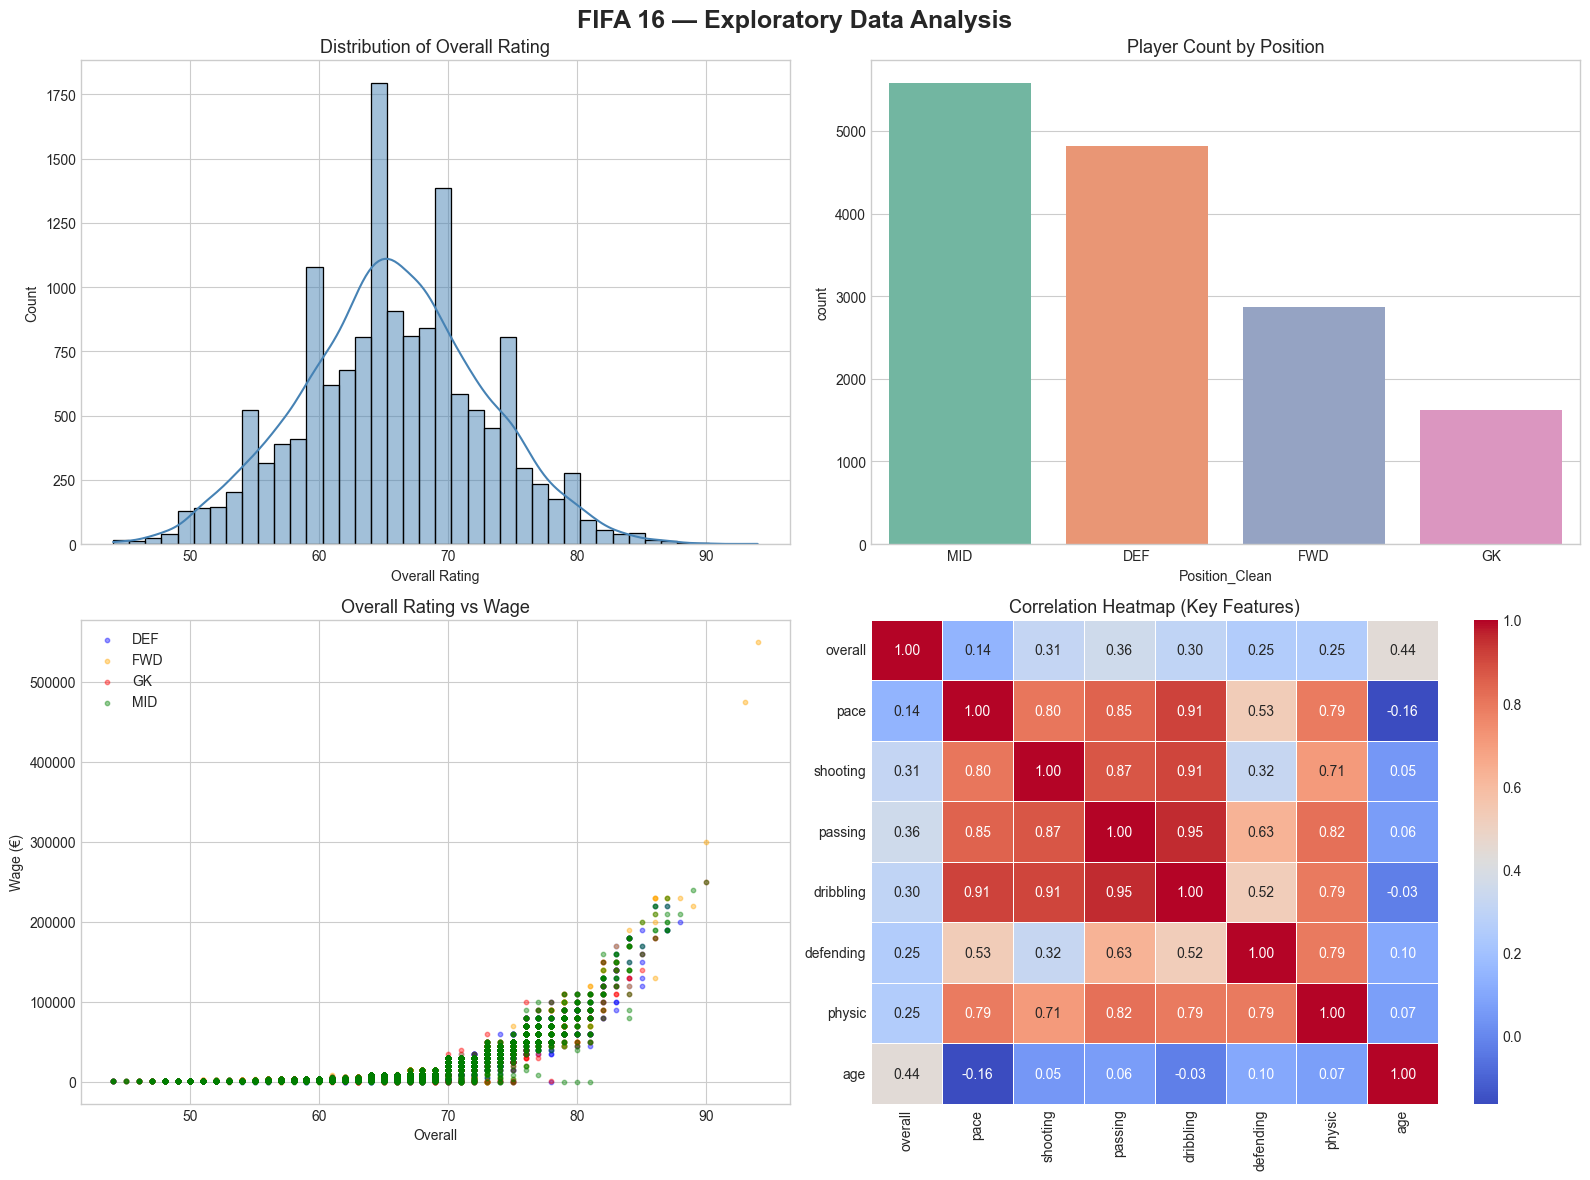

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FIFA 16 — Exploratory Data Analysis', fontsize=18, fontweight='bold')

# ── Plot 1: Distribution of Overall Rating ──
axes[0,0].set_title('Distribution of Overall Rating', fontsize=13)
sns.histplot(df_cleaned['overall'], kde=True, bins=40, color='steelblue', ax=axes[0,0])
axes[0,0].set_xlabel('Overall Rating')

# ── Plot 2: Countplot of Positions ──
axes[0,1].set_title('Player Count by Position', fontsize=13)
order = df_cleaned['Position_Clean'].value_counts().index
sns.countplot(data=df_cleaned, x='Position_Clean', order=order,
              palette='Set2', ax=axes[0,1])

# ── Plot 3: Scatter — Overall vs Wage ──
axes[1,0].set_title('Overall Rating vs Wage', fontsize=13)
colors = {'GK':'red','DEF':'blue','MID':'green','FWD':'orange'}
for pos, grp in df_cleaned.groupby('Position_Clean'):
    axes[1,0].scatter(grp['overall'], grp['wage_eur'],
                      label=pos, alpha=0.4, s=10, color=colors[pos])
axes[1,0].legend()
axes[1,0].set_xlabel('Overall'); axes[1,0].set_ylabel('Wage (€)')

# ── Plot 4: Correlation Heatmap ──
axes[1,1].set_title('Correlation Heatmap (Key Features)', fontsize=13)
key_feats = ['overall','pace','shooting','passing','dribbling','defending','physic','age']
key_feats = [f for f in key_feats if f in df_cleaned.columns]
corr = df_cleaned[key_feats].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,1], linewidths=0.5)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insights from Visualizations

1. **Overall Rating**: Normally distributed, centered ~66. Most players are average — few elite players exist (right tail).
2. **Position Distribution**: Dataset is imbalanced — DEF & MID are the majority. GK is the smallest group.
3. **Overall vs Wage**: Clear positive correlation. High-rated players earn significantly more. FWDs tend to earn most.
4. **Correlation Heatmap**: Shooting & Pace are highly correlated. Defending is negatively correlated with Shooting — confirms positional differences.

## ⚙️ Section 5: Feature Engineering

### Why Scaling is CRITICAL in KNN?
KNN calculates **Euclidean distance** between data points.
If one feature has range 0-100 (Overall) and another has range 0-100,000,000 (Wage), 
the Wage will **dominate** the distance calculation completely — 
making Overall irrelevant. Scaling brings ALL features to the same range.

In [13]:
# ── Create New Features ──
df_new = df_cleaned.copy()
# 1. Attacking Score
df_new['Attacking_Score'] = (df_cleaned['shooting'] + df_cleaned['pace'] + df_cleaned['dribbling']) / 3

# 2. Defensive Score  
df_new['Defensive_Score'] = (df_cleaned['defending'] + df_cleaned['physic']) / 2

# 3. Playmaking Score
df_new['Playmaking_Score'] = (df_cleaned['passing'] + df_cleaned['dribbling']) / 2

print("✅ 3 new features created:")
print(df_new[['Attacking_Score','Defensive_Score','Playmaking_Score']].describe())

✅ 3 new features created:
       Attacking_Score  Defensive_Score  Playmaking_Score
count     14881.000000     14881.000000      14881.000000
mean         54.363304        51.826794         53.038876
std          21.233593        21.448164         20.907427
min           0.000000         0.000000          0.000000
25%          50.333332        44.000000         49.000000
50%          60.333332        57.000000         59.000000
75%          67.666664        67.500000         66.000000
max          92.000000        87.000000         90.500000


In [14]:
# ── Select Features for Model ──
feature_cols = ['overall', 'age', 'height_cm', 'weight_kg', 'pace', 'shooting',
                'passing', 'dribbling', 'defending', 'physic', 'finishing', 'marking',
                'sliding_tackle', 'gk_diving']

feature_cols = [f for f in feature_cols if f in df_new.columns]

X = df_new[feature_cols]
y = df_new['Position_Clean']

# ── Encode Target ──
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")  # ['DEF' 'FWD' 'GK' 'MID']

Classes: ['DEF' 'FWD' 'GK' 'MID']


In [15]:
# ── Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── Apply StandardScaler ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # ⚠️ Only transform, never fit on test!

Train: (11904, 11) | Test: (2977, 11)


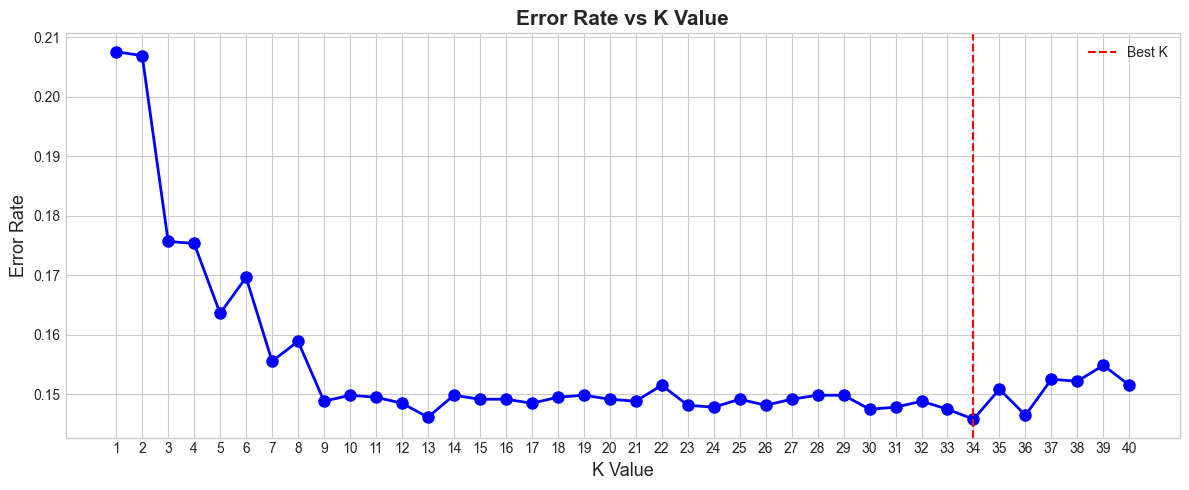

✅ Best K = 34 | Min Error Rate = 0.1458


In [16]:
# ── Find Best K ──
error_rates = []
k_range = range(1, 41)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, pred))

# ── Plot Error Rate vs K ──
plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, 'bo-', markersize=8, linewidth=2)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Error Rate', fontsize=13)
plt.title('Error Rate vs K Value', fontsize=15, fontweight='bold')
plt.xticks(k_range)
plt.axvline(x=error_rates.index(min(error_rates))+1, 
            color='red', linestyle='--', label=f'Best K')
plt.legend()
plt.tight_layout()
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"✅ Best K = {best_k} | Min Error Rate = {min(error_rates):.4f}")

In [17]:
# ── Train Final Model with Best K ──
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

🎯 Final Accuracy: 0.8542 (85.42%)


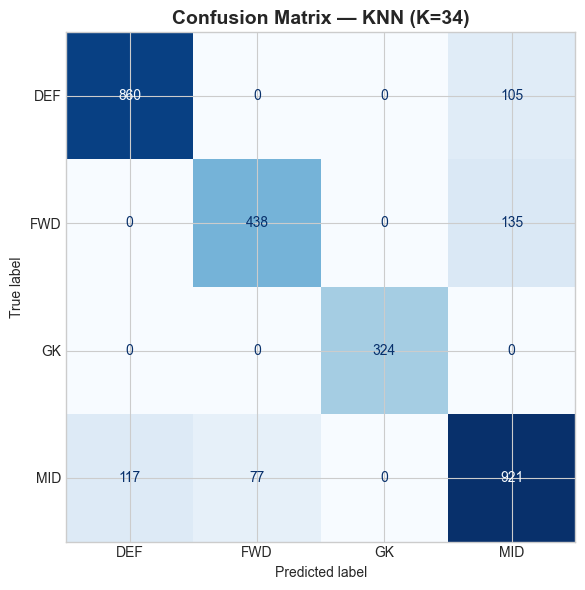


📊 Classification Report:
              precision    recall  f1-score   support

         DEF       0.88      0.89      0.89       965
         FWD       0.85      0.76      0.81       573
          GK       1.00      1.00      1.00       324
         MID       0.79      0.83      0.81      1115

    accuracy                           0.85      2977
   macro avg       0.88      0.87      0.88      2977
weighted avg       0.85      0.85      0.85      2977



In [18]:
# ── Accuracy ──
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Final Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — KNN (K={best_k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Classification Report ──
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## ✅ Section 8: Final Conclusion

| Metric | Value |
|--------|-------|
| Best K | [X] |
| Final Accuracy | [X]% |
| Best Predicted Class | GK (most distinct stats) |
| Hardest to Classify | MID/FWD overlap |

### Key Takeaways:
- **GK** is easiest to classify due to unique stats (high Defending, low Shooting)
- **MID and FWD** are sometimes confused due to overlapping attributes
- **Scaling was essential** — without it, Wage would dominate distance calculations
- **Feature Engineering improved** the model's ability to distinguish positions